# Flagging Vendor Invoices for Manual Review

## Objective
Predict whether a vendor invoice should be flagged for manual approval based on abnormal cost, freight, or delivery patterns, in order to reduce financial risk, improve operational efficiency, and prioritize human review where it adds the most value.

---

## Why this matters

- Manual invoice review is **time-consuming** and does not scale with transaction volume  
- Abnormal freight charges, pricing deviations, or delivery delays often indicate **errors, disputes, or compliance risks**  
- An automated flagging system enables finance teams to focus on **high-risk invoices** while allowing low-risk invoices to be processed automatically

In [274]:
import sqlite3
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [275]:
conn = sqlite3.connect("../data/inventory.db")

In [276]:
tables = pd.read_sql_query("SELECT name FROM sqlite_master WHERE type = 'table'", conn)
for table in tables['name']:
    print('Table name:', table)
    df=pd.read_sql_query(f"SELECT * FROM {table} LIMIT 5", conn)
    display(df)

Table name: begin_inventory


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,startDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,8,12.99,2024-01-01
1,1_HARDERSFIELD_60,1,HARDERSFIELD,60,Canadian Club 1858 VAP,750mL,7,10.99,2024-01-01
2,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,6,36.99,2024-01-01
3,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,3,38.99,2024-01-01
4,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,6,34.99,2024-01-01


Table name: end_inventory


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,endDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,11,12.99,2024-12-31
1,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,7,36.99,2024-12-31
2,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,7,38.99,2024-12-31
3,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,4,34.99,2024-12-31
4,1_HARDERSFIELD_75,1,HARDERSFIELD,75,Three Olives Tomato Vodka,750mL,7,14.99,2024-12-31


Table name: purchases


,InventoryId,Store,Brand,Description,Size,VendorNumber,VendorName,PONumber,PODate,ReceivingDate,InvoiceDate,PayDate,PurchasePrice,Quantity,Dollars,Classification
0,69_MOUNTMEND_8412,69,8412,Tequila Ocho Plata Fresno,750mL,105,ALTAMAR BRANDS LLC,8124,2023-12-21,2024-01-02,2024-01-04,2024-02-16,35.71,6,214.26,1
1,30_CULCHETH_5255,30,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,4,37.40,1
2,34_PITMERDEN_5215,34,5215,TGI Fridays Long Island Iced,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-02,2024-01-07,2024-02-21,9.41,5,47.05,1
3,1_HARDERSFIELD_5255,1,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,6,56.10,1
4,76_DONCASTER_2034,76,2034,Glendalough Double Barrel,750mL,388,ATLANTIC IMPORTING COMPANY,8169,2023-12-24,2024-01-02,2024-01-09,2024-02-16,21.32,5,106.60,1


Table name: purchase_prices


,Brand,Description,Price,Size,Volume,Classification,PurchasePrice,VendorNumber,VendorName
0,58,Gekkeikan Black & Gold Sake,12.99,750mL,750,1,9.28,8320,SHAW ROSS INT L IMP LTD
1,62,Herradura Silver Tequila,36.99,750mL,750,1,28.67,1128,BROWN-FORMAN CORP
2,63,Herradura Reposado Tequila,38.99,750mL,750,1,30.46,1128,BROWN-FORMAN CORP
3,72,No. 3 London Dry Gin,34.99,750mL,750,1,26.11,9165,ULTRA BEVERAGE COMPANY LLP
4,75,Three Olives Tomato Vodka,14.99,750mL,750,1,10.94,7245,PROXIMO SPIRITS INC.


Table name: vendor_invoice


,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,None
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,None
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,None
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,None
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,None


In [277]:
df = pd.read_sql_query("""
WITH purchase_agg AS (
    SELECT 
        p.PONumber,
        COUNT(DISTINCT Brand) as total_brands,
        SUM(Quantity) as total_item_quantity,
        SUM(Dollars) as total_item_dollars,
        AVG(JULIANDAY(ReceivingDate) - JULIANDAY(PODate)) as avg_receiving_delay
    FROM purchases p
    GROUP BY p.PONumber
)

SELECT
    vi.PONumber,
    vi.Quantity as invoice_quantity,
    vi.Dollars as invoice_dollars,
    vi.Freight,
    (JULIANDAY(vi.InvoiceDate) - JULIANDAY(vi.PODate)) as days_po_to_invoice,
    (JULIANDAY(vi.PayDate) - JULIANDAY(vi.InvoiceDate)) as days_to_pay,
    pa.total_brands,
    pa.total_item_quantity,
    pa.total_item_dollars,
    pa.avg_receiving_delay

FROM vendor_invoice vi
LEFT JOIN purchase_agg pa USING (PONumber)
""", conn)

In [278]:
df.head()

,PONumber,invoice_quantity,invoice_dollars,Freight,days_po_to_invoice,days_to_pay,total_brands,total_item_quantity,total_item_dollars,avg_receiving_delay
0,8124,6,214.26,3.47,14.0,43.0,1,6,214.26,12.000000
1,8137,15,140.55,8.57,16.0,45.0,2,15,140.55,10.333333
2,8169,5,106.60,4.61,16.0,38.0,1,5,106.60,9.000000
3,8106,10100,137483.78,2935.20,23.0,24.0,81,10100,137483.78,12.614130
4,8170,1935,15527.25,429.20,14.0,36.0,29,1935,15527.25,8.752809


In [279]:
df.isnull().sum()

PONumber               0
invoice_quantity       0
invoice_dollars        0
Freight                0
days_po_to_invoice     0
days_to_pay            0
total_brands           0
total_item_quantity    0
total_item_dollars     0
avg_receiving_delay    0
dtype: int64

In [280]:
df.dtypes

PONumber                 int64
invoice_quantity         int64
invoice_dollars        float64
Freight                float64
days_po_to_invoice     float64
days_to_pay            float64
total_brands             int64
total_item_quantity      int64
total_item_dollars     float64
avg_receiving_delay    float64
dtype: object

In [281]:
#Using rule-based flagging just for training, inference will be based on model not on rules
def create_invoice_risk_label(row):

    #Invoice total mismatch with item-level total
    if (abs(row["invoice_dollars"] - row["total_item_dollars"]) > 0.05):
        return 1

    #High receiving delay
    if row["avg_receiving_delay"] > 10:
        return 1
    else:
        return 0

df["flag_invoice"] = df.apply(create_invoice_risk_label, axis=1)
df["flag_invoice"].value_counts()

flag_invoice
0    3692
1    1851
Name: count, dtype: int64

<Axes: xlabel='flag_invoice'>

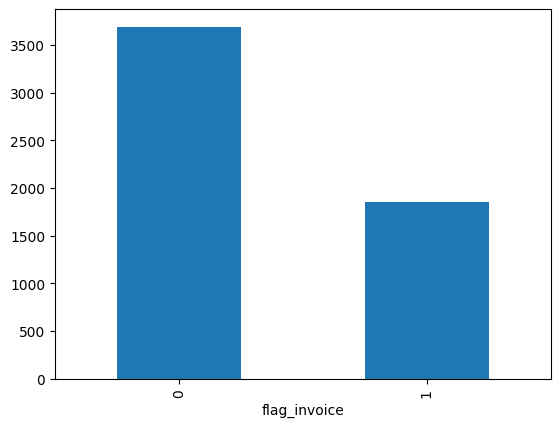

In [282]:
df["flag_invoice"].value_counts().plot(kind = 'bar')

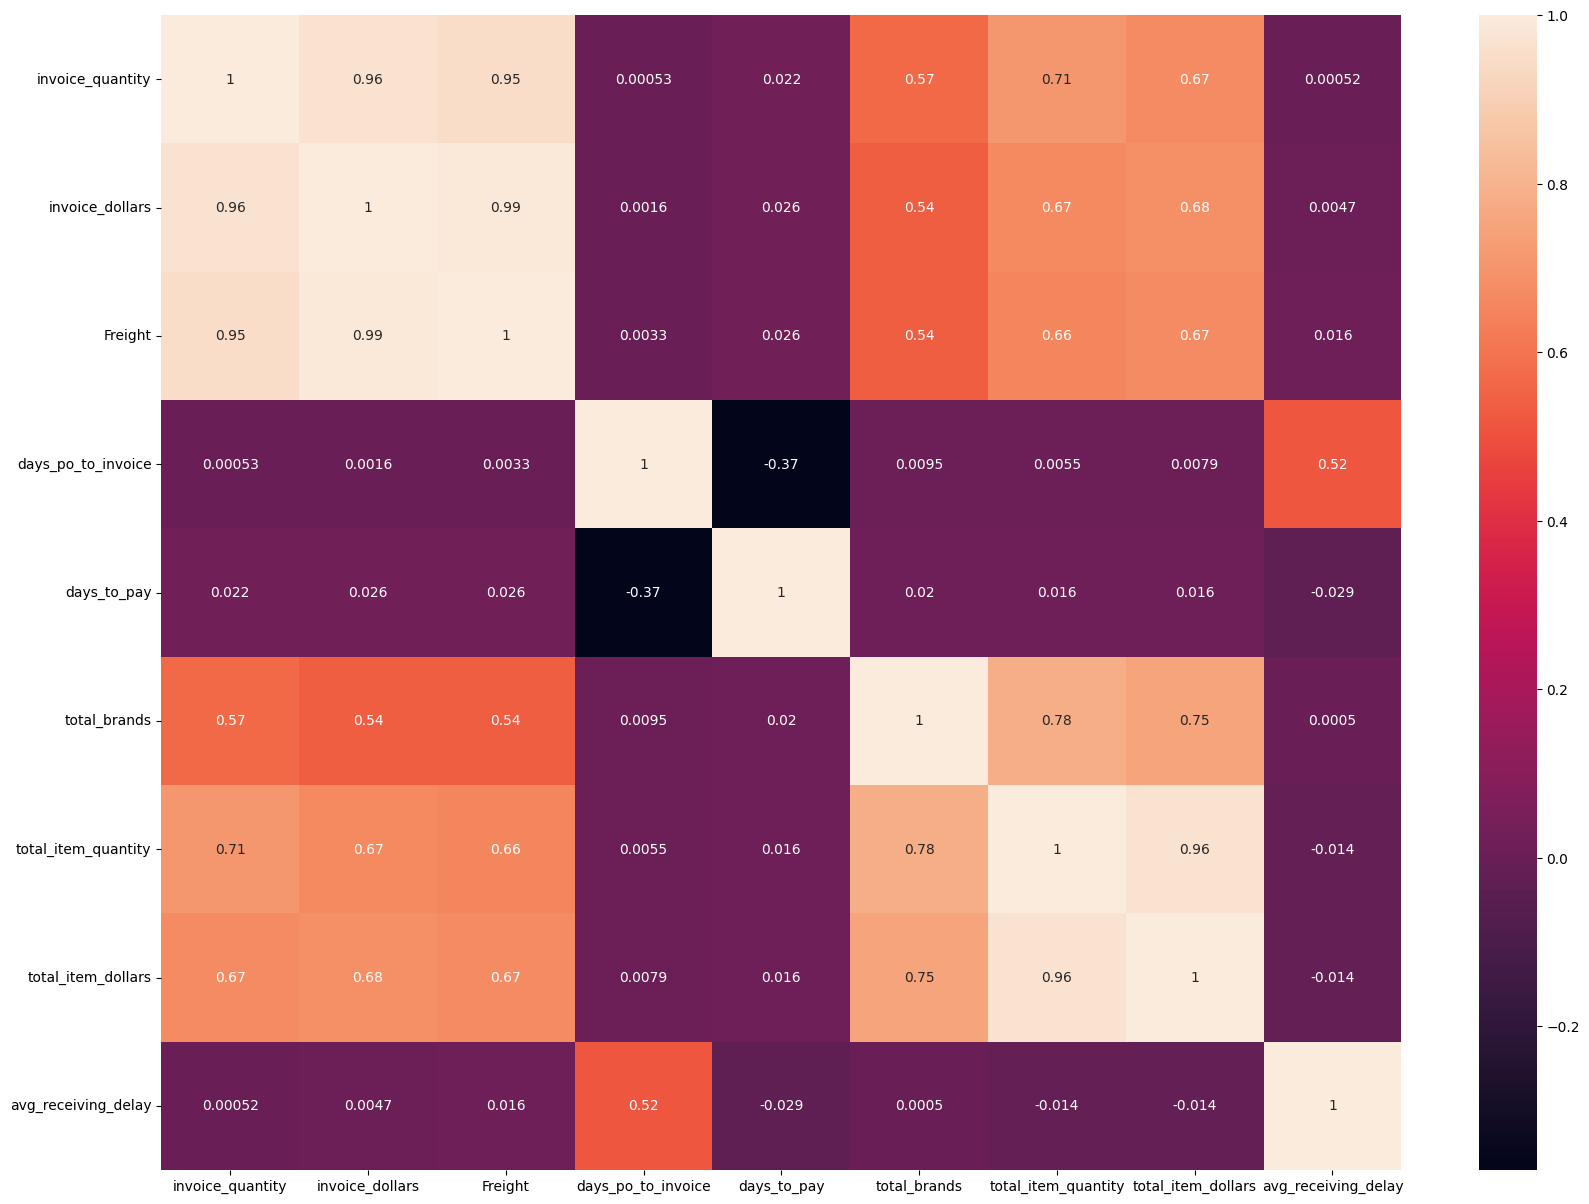

In [283]:
plt.figure(figsize=(20,15))
sns.heatmap(df.iloc[:,1:-1].corr(),annot=True)#Excluding PONumber and flag_invoice
plt.show()

In [284]:
flagged = df[df["flag_invoice"]==1]
normal = df[df["flag_invoice"]==0]

In [285]:
significant_features = []
insignificant_features = []
results = []

In [286]:
metrics = ['invoice_quantity', 'invoice_dollars', 'Freight', 'days_po_to_invoice', 'days_to_pay', 'total_brands', 'total_item_quantity', 'total_item_dollars', 'avg_receiving_delay']

In [287]:
from scipy.stats import ttest_ind
for metric in metrics:
    flagged_mean = flagged[metric].mean()
    normal_mean = normal[metric].mean()

    t_stat, p_value = ttest_ind(
        flagged[metric].dropna(),
        normal[metric].dropna(),
        equal_var=False
    )

    if p_value < 0.05:
        significant_features.append(metric)
        results.append({
        'metric': metric,
        'flagged_mean': flagged_mean.round(2),
        'normal_mean': normal_mean.round(2),
        'p_value': p_value.round(3)
        })
    else:
        insignificant_features.append(metric)
        print({
            "metric": metric,
            "flagged_mean": flagged_mean.round(2),
            "normal_mean": normal_mean.round(2),
            "p_value": p_value.round(3)})
        #Not much difference in flagged and normal means for insignificant features

{'metric': 'days_to_pay', 'flagged_mean': np.float64(35.43), 'normal_mean': np.float64(35.49), 'p_value': np.float64(0.702)}
{'metric': 'total_brands', 'flagged_mean': np.float64(42.26), 'normal_mean': np.float64(40.84), 'p_value': np.float64(0.517)}


In [288]:
insignificant_features

['days_to_pay', 'total_brands']

In [289]:
significant_features

['invoice_quantity',
 'invoice_dollars',
 'Freight',
 'days_po_to_invoice',
 'total_item_quantity',
 'total_item_dollars',
 'avg_receiving_delay']

In [290]:
results

[{'metric': 'invoice_quantity',
  'flagged_mean': np.float64(6724.65),
  'normal_mean': np.float64(5725.09),
  'p_value': np.float64(0.022)},
 {'metric': 'invoice_dollars',
  'flagged_mean': np.float64(65565.23),
  'normal_mean': np.float64(54317.32),
  'p_value': np.float64(0.008)},
 {'metric': 'Freight',
  'flagged_mean': np.float64(333.84),
  'normal_mean': np.float64(276.96),
  'p_value': np.float64(0.008)},
 {'metric': 'days_po_to_invoice',
  'flagged_mean': np.float64(17.23),
  'normal_mean': np.float64(16.02),
  'p_value': np.float64(0.0)},
 {'metric': 'total_item_quantity',
  'flagged_mean': np.float64(6724.65),
  'normal_mean': np.float64(5725.09),
  'p_value': np.float64(0.022)},
 {'metric': 'total_item_dollars',
  'flagged_mean': np.float64(65565.23),
  'normal_mean': np.float64(54317.32),
  'p_value': np.float64(0.008)},
 {'metric': 'avg_receiving_delay',
  'flagged_mean': np.float64(8.47),
  'normal_mean': np.float64(7.27),
  'p_value': np.float64(0.0)}]

In [291]:
X = df[['invoice_quantity','invoice_dollars','Freight','days_po_to_invoice','total_item_quantity','total_item_dollars','avg_receiving_delay']]
y = df['flag_invoice']

In [292]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [293]:
X.describe().round()#Scaling is needed as difference in the max value of features is very large

,invoice_quantity,invoice_dollars,Freight,days_po_to_invoice,total_item_quantity,total_item_dollars,avg_receiving_delay
count,5543.0,5543.0,5543.0,5543.0,5543.0,5543.0,5543.0
mean,6059.0,58073.0,296.0,16.0,6059.0,58073.0,8.0
std,14453.0,140234.0,714.0,3.0,14453.0,140234.0,2.0
min,1.0,4.0,0.0,9.0,1.0,4.0,3.0
25%,83.0,968.0,5.0,14.0,83.0,968.0,6.0
50%,423.0,4765.0,25.0,16.0,423.0,4765.0,8.0
75%,5100.0,44587.0,230.0,19.0,5100.0,44587.0,9.0
max,141660.0,1660436.0,8468.0,23.0,141660.0,1660436.0,13.0


In [294]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [295]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [296]:
model1 = LogisticRegression(random_state=42)
model1.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [297]:
model2 = DecisionTreeClassifier(random_state=42)
model2.fit(X_train_scaled, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [298]:
model3 = RandomForestClassifier(random_state=42)
model3.fit(X_train_scaled, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [299]:
from sklearn.metrics import classification_report
def evaluate_model(model, X_test, y_test, model_name):

    pred = model.predict(X_test)
    print(f"{model_name} performance:")
    print(f"Accuracy : {model.score(X_test, y_test)*100:.2f}%")
    print("Classification Report:")
    print(classification_report(y_test, pred))

    return

In [300]:
evaluate_model(model1, X_test_scaled, y_test, 'Logistic Regression')
evaluate_model(model2, X_test_scaled, y_test, 'Decision Tree Classifier')
evaluate_model(model3, X_test_scaled, y_test, 'Random Forest Classifier')
#Random Forest is giving the best accuracy

Logistic Regression performance:
Accuracy : 74.03%
Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.93      0.82       725
           1       0.74      0.38      0.50       384

    accuracy                           0.74      1109
   macro avg       0.74      0.66      0.66      1109
weighted avg       0.74      0.74      0.71      1109

Decision Tree Classifier performance:
Accuracy : 94.95%
Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.97      0.96       725
           1       0.94      0.91      0.93       384

    accuracy                           0.95      1109
   macro avg       0.95      0.94      0.94      1109
weighted avg       0.95      0.95      0.95      1109

Random Forest Classifier performance:
Accuracy : 96.03%
Classification Report:
              precision    recall  f1-score   support

           0       0.94      1.00      0.97       725
     

In [301]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [302]:
print("Training distribution:")
print(y_train.value_counts(normalize=True))

Training distribution:
flag_invoice
0    0.669147
1    0.330853
Name: proportion, dtype: float64


In [303]:
model1 = LogisticRegression(random_state=42)
model1.fit(X_train_scaled, y_train)
model2 = DecisionTreeClassifier(random_state=42)
model2.fit(X_train_scaled, y_train)
model3 = RandomForestClassifier(random_state=42)
model3.fit(X_train_scaled, y_train)
evaluate_model(model1, X_test_scaled, y_test, 'Logistic Regression')
evaluate_model(model2, X_test_scaled, y_test, 'Decision Tree Classifier')
evaluate_model(model3, X_test_scaled, y_test, 'Random Forest Classifier')
#We see a very slight better accuracy in Random Forest and also Standard Scaler Works well with most models and Handles outliers better

Logistic Regression performance:
Accuracy : 73.94%
Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.93      0.82       725
           1       0.74      0.38      0.50       384

    accuracy                           0.74      1109
   macro avg       0.74      0.66      0.66      1109
weighted avg       0.74      0.74      0.71      1109

Decision Tree Classifier performance:
Accuracy : 94.86%
Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.97      0.96       725
           1       0.95      0.90      0.92       384

    accuracy                           0.95      1109
   macro avg       0.95      0.94      0.94      1109
weighted avg       0.95      0.95      0.95      1109

Random Forest Classifier performance:
Accuracy : 95.76%
Classification Report:
              precision    recall  f1-score   support

           0       0.94      1.00      0.97       725
     

In [304]:
model3.feature_importances_

array([0.10125798, 0.1070972 , 0.09777193, 0.02674915, 0.16667771,
       0.19662019, 0.30382583])

In [305]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": model3.feature_importances_
}).sort_values(by="Importance", ascending=False)

feature_importance
#We will evaluate model again after removing days_po_to_invoice as it has negligible feature importance

,Feature,Importance
6,avg_receiving_delay,0.303826
5,total_item_dollars,0.196620
4,total_item_quantity,0.166678
1,invoice_dollars,0.107097
0,invoice_quantity,0.101258
2,Freight,0.097772
3,days_po_to_invoice,0.026749


In [306]:
X = df[['invoice_quantity','invoice_dollars','Freight','total_item_quantity','total_item_dollars','avg_receiving_delay']]
y = df['flag_invoice']
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
model1 = LogisticRegression(random_state=42)
model1.fit(X_train_scaled, y_train)
model2 = DecisionTreeClassifier(random_state=42)
model2.fit(X_train_scaled, y_train)
model3 = RandomForestClassifier(random_state=42)
model3.fit(X_train_scaled, y_train)
evaluate_model(model1, X_test_scaled, y_test, 'Logistic Regression')
evaluate_model(model2, X_test_scaled, y_test, 'Decision Tree Classifier')
evaluate_model(model3, X_test_scaled, y_test, 'Random Forest Classifier')
#Accuracy further increased by 1% so we'll keep this as our final input vector

Logistic Regression performance:
Accuracy : 74.12%
Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.93      0.82       725
           1       0.74      0.39      0.51       384

    accuracy                           0.74      1109
   macro avg       0.74      0.66      0.67      1109
weighted avg       0.74      0.74      0.71      1109

Decision Tree Classifier performance:
Accuracy : 95.49%
Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.98      0.97       725
           1       0.95      0.92      0.93       384

    accuracy                           0.95      1109
   macro avg       0.95      0.95      0.95      1109
weighted avg       0.95      0.95      0.95      1109

Random Forest Classifier performance:
Accuracy : 96.93%
Classification Report:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       725
     

In [307]:
param_grid = {
    "n_estimators": [100 ,200, 300],
    "max_depth": [None, 4, 5, 6],
    "min_samples_split": [2, 3, 5],
    "min_samples_leaf": [1, 2, 5],
    "criterion": ['gini', 'entropy']
}

In [308]:
from sklearn.model_selection import GridSearchCV

rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring='f1',#F1 Score is primary metric due to class imbalance
    cv=5,
    verbose=2,
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)
evaluate_model(grid_search, X_test_scaled, y_test, 'Random Forest Classifier')

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Random Forest Classifier performance:
Accuracy : 95.37%
Classification Report:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       725
           1       1.00      0.91      0.95       384

    accuracy                           0.97      1109
   macro avg       0.98      0.96      0.97      1109
weighted avg       0.97      0.97      0.97      1109



In [309]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test, grid_search.predict(X_test_scaled))

array([[725,   0],
       [ 34, 350]])

In [310]:
grid_search.best_params_

{'criterion': 'gini',
 'max_depth': None,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'n_estimators': 100}

## 🔍 Final Insights: Invoice Risk Detection

### 1. Business Problem Solved
An automated system was developed to identify high-risk vendor invoices that require manual review, reducing operational workload and improving financial oversight.

---

### 2. Key Drivers of Invoice Risk
The model identified the following factors as the most significant contributors to invoice risk:

- **Invoice Amount vs Item-Level Mismatch** → Indicates potential billing errors or discrepancies  
- **Receiving Delays** → Longer delays are strongly associated with higher risk  
- **Freight Costs** → Abnormal freight charges signal potential inefficiencies or anomalies  
- **Purchase Volume & Value** → Large or unusual orders increase likelihood of irregularities  

---

### 3. Statistical Validation
Hypothesis testing confirmed that several features (e.g., invoice dollars, freight, receiving delay) show statistically significant differences between flagged and non-flagged invoices, validating their importance in risk detection.

---

### 4. Model Performance & Selection
- Multiple models were evaluated: Logistic Regression, Decision Tree, and Random Forest  
- **Random Forest Classifier achieved the best performance**, capturing non-linear relationships in the data  
- Feature importance analysis enabled removal of low-impact features, improving model efficiency  

---

### 5. Key Finding
A combination of **financial discrepancies (invoice vs purchase), operational delays, and logistics costs** provides a strong signal for identifying risky invoices.

---

### 6. Business Impact
- Enables **automated prioritization of high-risk invoices**  
- Reduces unnecessary manual reviews  
- Improves **accuracy and efficiency of financial operations**  
- Scales effectively with increasing transaction volume  

---

### 7. Final Conclusion
The system successfully transforms rule-based risk identification into a scalable machine learning solution, allowing organizations to proactively detect anomalies and optimize invoice processing workflows.